# Load the dataframe

In [1]:
import pandas as pd

In [3]:
data_frame = pd.read_csv('data_small/TG_STAID000003.txt', skiprows=20, parse_dates=['    DATE'])

In [4]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG
0,3,37076,1860-05-01,57,0
1,3,37076,1860-05-02,5,0
2,3,37076,1860-05-03,14,0
3,3,37076,1860-05-04,14,0
4,3,37076,1860-05-05,7,0
...,...,...,...,...,...
59195,3,37076,2022-05-27,-9999,9
59196,3,37076,2022-05-28,-9999,9
59197,3,37076,2022-05-29,-9999,9
59198,3,37076,2022-05-30,-9999,9


# Show certain rows

In [6]:
data_frame[10:20]

,STAID,SOUID,DATE,TG,Q_TG
10,3,37076,1860-05-11,16,0
11,3,37076,1860-05-12,22,0
12,3,37076,1860-05-13,16,0
13,3,37076,1860-05-14,25,0
14,3,37076,1860-05-15,32,0
15,3,37076,1860-05-16,50,0
16,3,37076,1860-05-17,57,0
17,3,37076,1860-05-18,91,0
18,3,37076,1860-05-19,50,0
19,3,37076,1860-05-20,80,0


# Show certain colors

In [7]:
data_frame.columns

Index(['STAID', ' SOUID', '    DATE', '   TG', ' Q_TG'], dtype='str')

In [8]:
data_frame['   TG']

0          57
1           5
2          14
3          14
4           7
         ... 
59195   -9999
59196   -9999
59197   -9999
59198   -9999
59199   -9999
Name:    TG, Length: 59200, dtype: int64

In [10]:
data_frame[['   TG','    DATE']]

,TG,DATE
0,57,1860-05-01
1,5,1860-05-02
2,14,1860-05-03
3,14,1860-05-04
4,7,1860-05-05
...,...,...
59195,-9999,2022-05-27
59196,-9999,2022-05-28
59197,-9999,2022-05-29
59198,-9999,2022-05-30


# Simple statistics and filtering

In [25]:
float(data_frame.loc[data_frame['   TG'] != -9999]['   TG'].mean() / 10)

0.4841153116504665

In [26]:
float(data_frame.loc[data_frame['   TG'] != -9999]['   TG'].max() / 10)

26.7

In [24]:
float(data_frame.loc[data_frame['   TG'] != -9999]['   TG'].min() / 10)


-40.9

<Axes: >

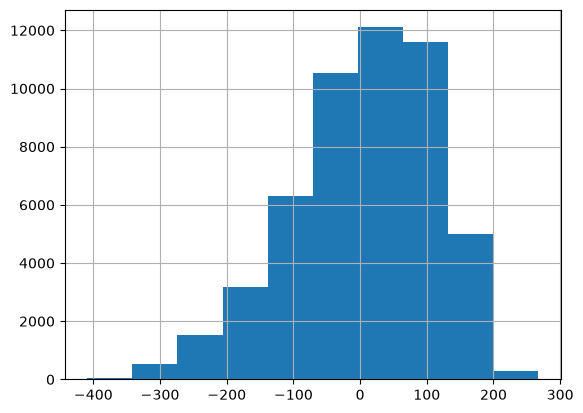

In [29]:
data_frame.loc[data_frame['   TG'] != -9999]['   TG'].hist()

In [30]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG
0,3,37076,1860-05-01,57,0
1,3,37076,1860-05-02,5,0
2,3,37076,1860-05-03,14,0
3,3,37076,1860-05-04,14,0
4,3,37076,1860-05-05,7,0
...,...,...,...,...,...
59195,3,37076,2022-05-27,-9999,9
59196,3,37076,2022-05-28,-9999,9
59197,3,37076,2022-05-29,-9999,9
59198,3,37076,2022-05-30,-9999,9


In [33]:
data_frame.loc[data_frame['    DATE']=='1860-05-05']['   TG'].squeeze() / 10

np.float64(0.7)

In [36]:
data_frame[data_frame['   TG'] == data_frame['   TG'].max()]['    DATE'].squeeze()

Timestamp('1876-06-23 00:00:00')

In [41]:
int(data_frame.loc[3, '   TG'])

14

# Calculate a new column

In [42]:
data_frame['TG'] = data_frame['   TG']/10

In [43]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG,TG
0,3,37076,1860-05-01,57,0,5.7
1,3,37076,1860-05-02,5,0,0.5
2,3,37076,1860-05-03,14,0,1.4
3,3,37076,1860-05-04,14,0,1.4
4,3,37076,1860-05-05,7,0,0.7
...,...,...,...,...,...,...
59195,3,37076,2022-05-27,-9999,9,-999.9
59196,3,37076,2022-05-28,-9999,9,-999.9
59197,3,37076,2022-05-29,-9999,9,-999.9
59198,3,37076,2022-05-30,-9999,9,-999.9


In [45]:
data_frame['Fahrehneit'] = data_frame["TG"] * (9/5) +  32

In [46]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG,TG,Fahrehneit
0,3,37076,1860-05-01,57,0,5.7,42.26
1,3,37076,1860-05-02,5,0,0.5,32.90
2,3,37076,1860-05-03,14,0,1.4,34.52
3,3,37076,1860-05-04,14,0,1.4,34.52
4,3,37076,1860-05-05,7,0,0.7,33.26
...,...,...,...,...,...,...,...
59195,3,37076,2022-05-27,-9999,9,-999.9,-1767.82
59196,3,37076,2022-05-28,-9999,9,-999.9,-1767.82
59197,3,37076,2022-05-29,-9999,9,-999.9,-1767.82
59198,3,37076,2022-05-30,-9999,9,-999.9,-1767.82


# Plotting

<Axes: >

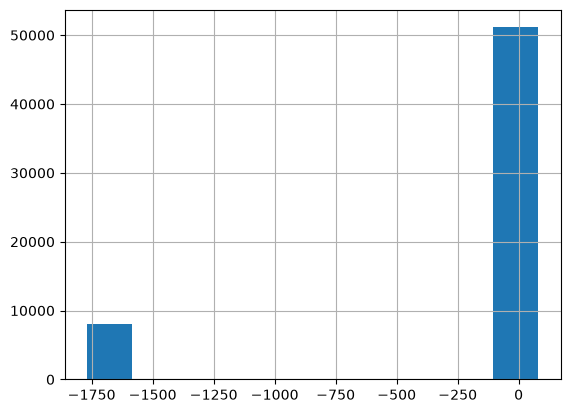

In [55]:
celsius = data_frame['   TG'] / 10
data_frame['Fahrenheit'] = (celsius * 9/5) + 32

data_frame["Fahrenheit"].hist()

<Axes: xlabel='    DATE'>

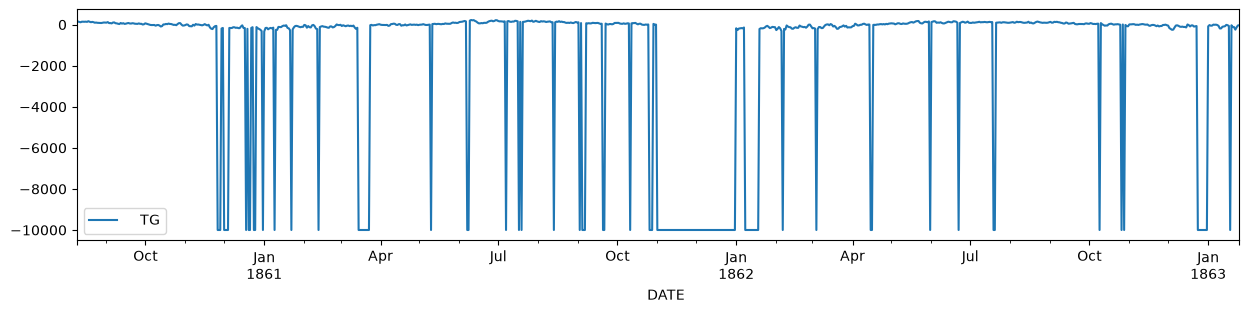

In [58]:
data_frame[100:1000].plot(x='    DATE', y='   TG', figsize=(15, 3))